# Hurricane Ike (Sep 2008): Gulf MOM6 with full ERA5 atmosphere (CrocoDash)

**Author: Faezeh Maghsoodifar, The University of Alabama**  
**ERA5 CrocoDash extension and regional MOM6 workflow, 2026**

> This executed example documents the successful Hurricane Ike application. It builds on CrocoDash, CROCODILE, CESM, CDEPS, CMEPS, MOM6, and community datasets. See the repository `NOTICE` and `CITATION.cff` files for complete attribution.

Separate notebook for **ike**: case `gom12_ike_ERA5full.001`, with ERA5 supplying all eight atmospheric forcing streams. Existing cases and notebooks are not touched.

**Where to run:** NCAR JupyterHub on **Casper**, kernel **CrocoDash**, 40 GB or more memory.
Build and run happen in a **Derecho** terminal (section 6).

**Before running:** install the private ERA5 CrocoDash branch and run `era5_crocodash/prepare_era5_tutorial.pbs`. Then run cells top to bottom **once**. Do **not** re-run the `Case(...)` cell later: it wipes and recreates this case.

Lessons from the first run are built in:
- `DT` is not added twice (4b).
- section 5 writes the diag_table without needing `preview_namelists` first, and hourly output uses `SSH_inst`.
- `case.setup --reset` and the `tutorial` queue (6).
- the output calendar fix (7).


In [1]:
import inspect
from CrocoDash.forcing.atm import ERA5AtmosphereConfigurator

print(inspect.getfile(ERA5AtmosphereConfigurator))
print(ERA5AtmosphereConfigurator.name)

/glade/work/faezehmaghso/crocodile2026/CrocoDash-era5/CrocoDash/forcing/atm.py
ERA5Atmosphere


## 0. Settings — edit this cell only

In [1]:
import inspect
import os
from pathlib import Path
from CrocoDash.forcing.atm import ERA5AtmosphereConfigurator

# --- event: run this notebook once per event -> one CESM case each ---
EVENT = "ike"           # this notebook is for ike only
EVENTS = {
    # 10+ days spin-up before the storm enters the Gulf
    "katrina": ["2005-08-15 00:00:00", "2005-09-05 00:00:00"],  # landfall 29 Aug 2005 (LA/MS)
    "ike":     ["2008-08-30 00:00:00", "2008-09-20 00:00:00"],  # landfall 13 Sep 2008 (Galveston)
}
DATE_RANGE = EVENTS[EVENT]
CASENAME   = "gom12_ike_ERA5full.001"
GRID_NAME  = "gom12_ike_ERA5full"   # unique per case: CESM registers grid names globally

# --- paths (match your CROCODILEworkspace install) ---
WORKSPACE = Path("/glade/work/faezehmaghso/crocodile2026")
CESMROOT  = WORKSPACE / "CESM"                      # CESM checkout made by install.sh
INPUTDIR  = WORKSPACE / "croc_input" / CASENAME
CASEROOT  = WORKSPACE / "croc_cases" / CASENAME

PROJECT   = "UCGD0009"   # workshop project; replace with your own NCAR project code

# --- data on GLADE (from CrocoGallery/crocogallery/known_paths.json) ---
GEBCO  = Path("/glade/campaign/cgd/oce/projects/CROCODILE/workshops/2026/CrocoDash/data/gebco_2026/GEBCO_2026_coarse_x8.nc")
TPXO_H = "/glade/campaign/cesm/cesmdata/inputdata/ocn/mom/croc/crocogallerydata/tpxo/h_tpxo9.v1.nc"
TPXO_U = "/glade/campaign/cesm/cesmdata/inputdata/ocn/mom/croc/crocogallerydata/tpxo/u_tpxo9.v1.nc"

# --- full ERA5 atmosphere, prepared by era5_crocodash/prepare_era5_tutorial.pbs ---
ERA5_FORCE_DIR = WORKSPACE / "era5_forcing" / "ike2008"
ERA5_FILE = ERA5_FORCE_DIR / "era5_atmos_ike2008.nc"
ERA5_MESH = ERA5_FORCE_DIR / "era5_025_ESMFmesh.nc"
ERA5_FIELDS = {field: ERA5_FILE for field in ("precip", "lwdn", "swdn", "q2m", "msl", "t2m", "u10", "v10")}

# --- domain: whole Gulf of Mexico + NW Caribbean ---
# Longitudes in [0, 360]:  262 = 98W,  282 = 78W ... east edge at 82W cuts the Florida Straits.
RES    = 1/12      # deg (~9 km)
XSTART = 262.0     # 98W
LENX   = 16.0      # -> 82W
YSTART = 18.0
LENY   = 13.0      # -> 31N (north edge on land)
MIN_DEPTH = 5.0    # m; fall back to 9.5 (tutorial value) if the run is unstable
NK = 50            # vertical levels

# --- tides ---
TIDAL_CONSTITUENTS = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]

# --- compute ---
NTASKS_OCN = 128           # one Derecho CPU node
JOB_QUEUE  = "main"
WALLCLOCK  = "02:00:00"

era5_code = Path(inspect.getfile(ERA5AtmosphereConfigurator)).resolve()
print(f"ERA5 CrocoDash code: {era5_code}")
assert ERA5AtmosphereConfigurator.name == "ERA5Atmosphere", (
    "The ERA5-enabled private CrocoDash is not active in this kernel. "
    "Install CrocoDash-era5, restart the kernel, and rerun this cell."
)
assert GEBCO.exists(), f"GEBCO not found: {GEBCO}"
assert CESMROOT.exists(), f"CESM not found: {CESMROOT}"
assert ERA5_FILE.exists(), f"Prepared ERA5 file not found: {ERA5_FILE}"
assert ERA5_MESH.exists(), f"ERA5 ESMF mesh not found: {ERA5_MESH}"

ERA5 CrocoDash code: /glade/work/faezehmaghso/crocodile2026/CrocoDash-era5/CrocoDash/forcing/atm.py


### 0a. Reuse the ERA5 CrocoDash bundle for another time window

The Git bundle `crocodash-era5.bundle` contains the **date-independent CrocoDash ERA5 integration code**. It does not need to be rebuilt or reinstalled for another event or date range. The ERA5 ESMF mesh is also independent of time and can be reused while the ERA5 spatial grid remains unchanged.

The prepared atmospheric file, such as `era5_atmos_ike2008.nc`, **is time-specific**. A simulation outside its coverage requires a new prepared ERA5 NetCDF file. The new period must be consistent in three places:

1. the dates selected by `prepare_era5_tutorial.pbs`;
2. `DATE_RANGE` in the settings cell above; and
3. the time coverage of the resulting `ERA5_FILE`.

#### If only the analysis window changes

No ERA5 preparation or MOM6 rerun is needed when the requested analysis dates fall inside the completed run (`2008-08-30 00:00` through `2008-09-20 00:00`). Select the desired period directly from the saved output:

```python
analysis = g["SSH_inst"].sel(time=slice("2008-09-09", "2008-09-15"))
```

#### If the MOM6 simulation window changes

Keep the installed ERA5-enabled CrocoDash branch and bundle. In a **Derecho shell**, make a copy of the preparation script, find its date settings, edit the dates and output path, and submit the new copy:

```bash
cd /glade/work/faezehmaghso/crocodile2026/era5_crocodash
cp prepare_era5_tutorial.pbs prepare_era5_NEW_EVENT.pbs
grep -nEi 'start|end|date|year|month|2008|200809' prepare_era5_NEW_EVENT.pbs
# Edit the copied script: set the new start/end dates and a new output directory/file.
qsub -V prepare_era5_NEW_EVENT.pbs
```

Then update the settings cell with matching dates and new names. For example:

```python
EVENTS["ike_extended"] = ["2008-08-25 00:00:00", "2008-09-25 00:00:00"]
EVENT = "ike_extended"
DATE_RANGE = EVENTS[EVENT]
CASENAME = "gom12_ike_ERA5full_extended.001"
GRID_NAME = "gom12_ike_ERA5full_extended"
ERA5_FORCE_DIR = WORKSPACE / "era5_forcing" / "ike2008_extended"
ERA5_FILE = ERA5_FORCE_DIR / "era5_atmos_ike2008_extended.nc"
ERA5_MESH = WORKSPACE / "era5_forcing" / "ike2008" / "era5_025_ESMFmesh.nc"
ERA5_FIELDS = {field: ERA5_FILE for field in ("precip", "lwdn", "swdn", "q2m", "msl", "t2m", "u10", "v10")}
```

Always use a new `CASENAME`, `GRID_NAME`, forcing directory and forcing filename for a new simulation. This prevents the successful Ike case from being overwritten. The forcing file must contain the full requested interval; retaining a final record that brackets the model end time is safest for temporal interpolation. After preparation finishes, run the coverage check below before creating the CrocoDash case.

In [ ]:
# Read metadata only; this does not load the 7+ GB ERA5 file into memory.
import pandas as pd
import xarray as xr

with xr.open_dataset(ERA5_FILE) as era5_check:
    if "time" not in era5_check.coords:
        raise KeyError(f"ERA5 file has no time coordinate: {ERA5_FILE}")
    forcing_start = pd.Timestamp(era5_check.time.values[0])
    forcing_end = pd.Timestamp(era5_check.time.values[-1])
    forcing_records = era5_check.sizes["time"]
    forcing_variables = list(era5_check.data_vars)

requested_start = pd.Timestamp(DATE_RANGE[0])
requested_end = pd.Timestamp(DATE_RANGE[1])

print("ERA5 bundle/code: reusable for any supported period")
print("ERA5 file:", ERA5_FILE)
print("ERA5 coverage:", forcing_start, "to", forcing_end)
print("Requested run:", requested_start, "to", requested_end)
print("Hourly records:", forcing_records)
print("Variables:", forcing_variables)

assert forcing_start <= requested_start, (
    f"ERA5 starts too late: {forcing_start} > {requested_start}"
)
assert forcing_end >= requested_end, (
    f"ERA5 ends too early: {forcing_end} < {requested_end}"
)
print("PASS: the prepared ERA5 file covers DATE_RANGE.")

## 1. Horizontal grid

In [2]:
from CrocoDash.grid import Grid

grid = Grid(
    resolution=RES,
    xstart=XSTART,
    lenx=LENX,
    ystart=YSTART,
    leny=LENY,
    name=GRID_NAME,
)
print(f"nx={grid.nx}, ny={grid.ny}, cells={grid.nx * grid.ny:,}")

nx=192, ny=156, cells=29,952


## 2. Topography

GEBCO 2026 coarsened ×8 (~2 arc-min), enough for 1/12°. `keep_largest_basin()` removes lakes and isolated ponds.

Slicing source bathymetry to domain: (262.0, 278.0) x (18.0, 31.0) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2026_coarse_x8.nc):
    dlon = 120.0 arcsec  (0.033333°)
    dlat = 120.0 arcsec  (0.033333°)
    dx   ~ 3535 m)
    dy   ~ 3706 m

  Model grid (T-cell spacing):
    median = 8.84 km
    min    = 8.58 km
    max    = 9.04 km

  Resolution ratio (model dx / dataset dx):
    median = 2.5x
    max    = 2.6x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: direct_xesmf_regrid()  (bilinear / conservative)
    Ratio 2.5x is below the threshold where Cressman
    likely provides benefit over xesmf regridding.
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_depth_from_xesmf()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            `

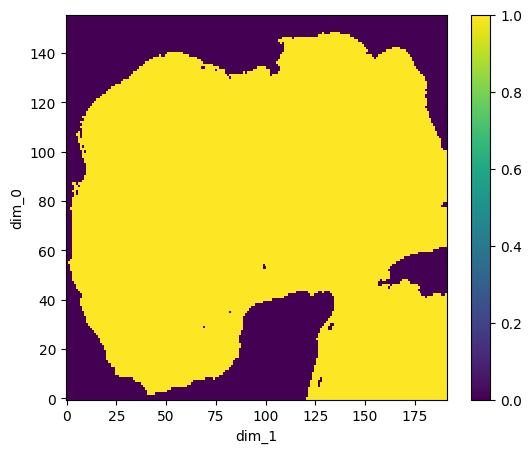

In [3]:
from CrocoDash.topo import Topo

topo = Topo(grid=grid, min_depth=MIN_DEPTH)
topo.set_from_dataset(
    bathymetry_path=GEBCO,
    longitude_coordinate_name="lon",
    latitude_coordinate_name="lat",
    vertical_coordinate_name="elevation",
    depth_method="xesmf",
    mask_method="dataset",
)
topo.keep_largest_basin()
topo.basintmask.plot(size=5, aspect=grid.nx / grid.ny)
print(f"max depth = {float(topo.max_depth):.0f} m")

### 2b. Which edges are open?

Expected: **south** (NW Caribbean → Yucatán inflow) and **east** (Florida Straits outflow).
**north** and **west** should be all land. If not, adjust the domain before continuing.

In [4]:
import numpy as np

wet = np.asarray(topo.tmask) > 0          # 1 = ocean
assert wet.shape == (grid.ny, grid.nx), wet.shape

edges = {"south": wet[0, :], "north": wet[-1, :], "west": wet[:, 0], "east": wet[:, -1]}
for name, e in edges.items():
    print(f"{name:5s}: {int(e.sum()):4d} wet of {e.size}")

BOUNDARIES = [name for name, e in edges.items() if e.any()]
print("open boundaries:", BOUNDARIES)
if {"north", "west"} & set(BOUNDARIES):
    print("WARNING: north/west edge has water -- review the domain before going on.")

south:   71 wet of 192
north:    0 wet of 192
west :    0 wet of 156
east :   80 wet of 156
open boundaries: ['south', 'east']


## 3. Vertical grid

In [5]:
from CrocoDash.vgrid import VGrid

vgrid = VGrid.hyperbolic(nk=NK, depth=topo.max_depth, ratio=50.0)
print("top layer thickness ~", float(vgrid.zi[1] - vgrid.zi[0]), "m")

top layer thickness ~ 4.917423209206984 m


## 4. CESM case + forcings

`CR_JRA` = ocean-only MOM6 with JRA55-do data atmosphere. Sea-level pressure is passed to MOM6, so the inverse-barometer effect is in η (report §A2).

In [6]:
# Safety check: stop if anything points at the wrong event or at an existing case
for p in [CASEROOT, INPUTDIR]:
    assert "gom12_ike" in str(p), f"STOP: {p} is not a ike folder"
assert not CASEROOT.exists(), f"STOP: {CASEROOT} already exists (do not re-run Case; go to section 7)"
print("Safe: ike case will be created in")
print("  ", CASEROOT)
print("  ", INPUTDIR)

Safe: ike case will be created in
   /glade/work/faezehmaghso/crocodile2026/croc_cases/gom12_ike_ERA5full.001
   /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001


In [7]:
from CrocoDash.case import Case

case = Case(
    cesmroot=CESMROOT,
    caseroot=CASEROOT,
    inputdir=INPUTDIR,
    ocn_grid=grid,
    ocn_vgrid=vgrid,
    ocn_topo=topo,
    compset="CR_JRA",
    machine="derecho",
    project=PROJECT,
    ntasks_ocn=NTASKS_OCN,
    job_queue=JOB_QUEUE,
    job_wallclock_time=WALLCLOCK,
    override=True,
)

WARNING [CIME.XML.grids] Schema validity test fails for /glade/work/faezehmaghso/crocodile2026/CESM/ccs_config/config_grids_nuopc.xml


Creating case...

Running the create_newcase tool with the following command:

/glade/work/faezehmaghso/crocodile2026/CESM/cime/scripts/create_newcase --compset CR_JRA --res USER_RES --case /glade/work/faezehmaghso/crocodile2026/croc_cases/gom12_ike_ERA5full.001 --machine derecho --run-unsupported --handle-preexisting-dirs a --project UCGD0009 --non-local 

The create_newcase command was successful.

• Updating case xml variables to include newly generated ocean grid "gom12_ike_ERA5full" with the following properties:
 nx: 192, ny: 156. ocean mesh: /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/ocn/ESMF_mesh_gom12_ike_ERA5full_2a8e8e.nc.

./xmlchange OCN_GRID=gom12_ike_ERA5full --non-local
./xmlchange OCN_NX=192 --non-local
./xmlchange OCN_NY=156 --non-local
./xmlchange OCN_DOMAIN_MESH=/glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/ocn/ESMF_mesh_gom12_ike_ERA5full_2a8e8e.nc --non-local
./xmlchange ICE_GRID=gom12_ike_ERA5full --non-loc

In [8]:
# Full ERA5 atmosphere: JRA remains only the CDEPS field interface.
case.configure_forcings(
    date_range=DATE_RANGE,
    boundaries=BOUNDARIES,
    product_name="GLORYS",
    function_name="get_glorys_data_from_rda",
    tpxo_elevation_filepath=TPXO_H,
    tpxo_velocity_filepath=TPXO_U,
    tidal_constituents=TIDAL_CONSTITUENTS,
    era5_atmosphere_files=ERA5_FIELDS,
    era5_mesh_filepath=ERA5_MESH,
    era5_atmosphere_mode="full",
)

INFO [CrocoDash.forcing.base] [REQUIRED] Activating StreamYears
INFO [CrocoDash.forcing.base] [OPTIONAL] Activating ERA5Atmosphere
INFO [CrocoDash.forcing.base] [SKIP] BGC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIC incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCIronForcing incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] BGCRiverNutrients incompatible with compset
INFO [CrocoDash.forcing.base] [SKIP] Chl missing args: ['chl_processed_filepath']
INFO [CrocoDash.forcing.base] [SKIP] CICE incompatible with compset
INFO [CrocoDash.forcing.base] [REQUIRED] Activating conditions
INFO [CrocoDash.forcing.base] [SKIP] Runoff incompatible with compset
INFO [CrocoDash.forcing.base] [OPTIONAL] Activating tides
INFO [CrocoDash.forcing.base] [SKIP] WW3 incompatible with compset
INFO [CrocoDash.forcing.base] Configuring StreamYears


WARNING [CrocoDash.forcing.atm] DROF stream years left at CESM defaults: no active drof


Adding parameter changes to user_nl_datm_streams:

  ! Align CORE_IAF_JRA_1p5_2023 streams with the run dates (CrocoDash: CDEPS defaults to year_align=1)
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_first = 2006
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_last = 2009
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:year_align = 2006
  CORE_IAF_JRA_1p5_2023.GCGCS.PREC:datafiles = /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2006.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2007.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2008.210504.nc,/glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1.5_noleap/JRA.v1.5.prec.TL319.2009.210504.nc
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_first = 2006
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_last = 2009
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:year_align = 2006
  CORE_IAF_JRA_1p5_2023.GISS.LWDN:datafiles = /glade/campaign/cesm/cesmdata/inputdata/ocn/jra55/v1

In [9]:
# Slowest step: cuts GLORYS IC + OBCs from RDA, regrids them, and regrids TPXO onto each open edge.
case.process_forcings()

Processing south boundary...

WARNING [regional_mom6.regridding] All NaNs filled b/c no ocean/land mask was available. Pass a topo to Segment construction to avoid this.
WARNING [regional_mom6.validate] zamp_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var zamp_segment_001, it should be of the form dz_zamp_segment_001
WARNING [regional_mom6.validate] zphase_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var zphase_segment_001, it should be of the form dz_zphase_segment_001
WARNING [regional_mom6.regridding] All NaNs filled b/c no ocean/land mask was available. Pass a topo to Segment construction to avoid this.
WARNING [regional_mom6.validate] uamp_segment_001 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var uamp_segment_001, it should be of the form dz_uamp_segment_001
WARNING [regional_mom6.validate] vamp_segment

Done
Processing east boundary...

WARNING [regional_mom6.regridding] All NaNs filled b/c no ocean/land mask was available. Pass a topo to Segment construction to avoid this.
WARNING [regional_mom6.validate] zamp_segment_002 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var zamp_segment_002, it should be of the form dz_zamp_segment_002
WARNING [regional_mom6.validate] zphase_segment_002 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var zphase_segment_002, it should be of the form dz_zphase_segment_002
WARNING [regional_mom6.regridding] All NaNs filled b/c no ocean/land mask was available. Pass a topo to Segment construction to avoid this.
WARNING [regional_mom6.validate] uamp_segment_002 does not have a coordinates attribute
WARNING [regional_mom6.validate] Cannot find thickness variable for var uamp_segment_002, it should be of the form dz_uamp_segment_002
WARNING [regional_mom6.validate] vamp_segment

Done
INFO [CrocoDash.forcing.obc] Using tmask-derived bounding boxes for OBC data download.
INFO [CrocoDash.forcing.obc] GET [south]: 2008-08-30 → 2008-09-20
INFO [GLORYS] Downloading Glorys data from RDA to /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/extract_forcings/raw_data/south_unprocessed.2008-08-30_2008-09-05.nc
INFO [GLORYS] Download of /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/extract_forcings/raw_data/south_unprocessed.2008-08-30_2008-09-05.nc complete.
INFO [GLORYS] Downloading Glorys data from RDA to /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/extract_forcings/raw_data/south_unprocessed.2008-09-06_2008-09-12.nc
INFO [GLORYS] Download of /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/extract_forcings/raw_data/south_unprocessed.2008-09-06_2008-09-12.nc complete.
INFO [GLORYS] Downloading Glorys data from RDA to /glade/work/faezehmaghso/crocodile2026/croc_input/go

...

This means that some areas may only have one or two layers between the surface and sea floor. 
For increased stability, consider increasing the minimum depth, or adjusting the vertical coordinate to add more layers near the surface.
No arakawa_grid provided, assuming the variable mapping for your data product is already in correct format.
Arakawa A grid detected in variable mapping


WARNING [regional_mom6.utils] regional_mom6 could not use pint for data array temp, assuming it's in the correct units


Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

WARNING [regional_mom6.validate] eta_t does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable eta_t does not have 4 dimensions
WARNING [regional_mom6.validate] temp does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable temp does not have 4 dimensions
WARNING [regional_mom6.validate] salt does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable salt does not have 4 dimensions
WARNING [regional_mom6.validate] u does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable u does not have 4 dimensions
WARNING [regional_mom6.validate] v does not have a coordinates attribute
WARNING [regional_mom6.validate] Variable v does not have 4 dimensions


INFO [CrocoDash.forcing.mom6] Start mom6_forge fill...
INFO [CrocoDash.forcing.mom6] ...end mom6_forge fill.
INFO [CrocoDash.forcing.ic] Successfully retrieved GLORYS initial condition data located in /glade/work/faezehmaghso/crocodile2026/croc_input/gom12_ike_ERA5full.001/ocn directory.
[timing] tides: 75.2s  bc: 274.2s  ic: 18.7s  total: 368.1s
Case is ready to be built: /glade/work/faezehmaghso/crocodile2026/croc_cases/gom12_ike_ERA5full.001


### 4b. Extra MOM6 parameters

- CrocoDash turns on only `TIDE_M2` for the body (astronomical) tide (`CrocoDash/forcing/tides.py:86`). Galveston is diurnal, so turn on the rest.
- CrocoDash sets no `DT` for custom grids. 600 s matches the SeaSloth benchmark runs at ~0.1°.

Entries outside CrocoDash's own `! >>> CrocoDash` blocks are kept and take precedence (`Case.configure_forcings` docstring).

In [10]:
import re

TAG = "! >>> added by 01_build_gulf_mom6.ipynb"
wanted = {"DT": "600.0"}
wanted.update({f"TIDE_{c}": "True" for c in TIDAL_CONSTITUENTS if c != "M2"})

user_nl = CASEROOT / "user_nl_mom"
text = user_nl.read_text()

# Parameters already set anywhere in user_nl_mom (MOM_interface rejects duplicates).
present = set()
for line in text.splitlines():
    s = line.strip()
    if not s or s.startswith("!"):
        continue
    s = s.replace("#override", "").strip()
    m = re.match(r"(\w+)\s*=", s)
    if m:
        present.add(m.group(1))

missing = {k: v for k, v in wanted.items() if k not in present}
if missing:
    block = [TAG] + [f"{k} = {v}" for k, v in missing.items()] + ["! <<< added by 01_build_gulf_mom6.ipynb", ""]
    user_nl.write_text(text.rstrip() + "\n\n" + "\n".join(block))
print("added:", list(missing) or "nothing (all already present)")
print("skipped (already set):", sorted(set(wanted) & present))


added: ['TIDE_S2', 'TIDE_N2', 'TIDE_K2', 'TIDE_K1', 'TIDE_O1', 'TIDE_P1', 'TIDE_Q1']
skipped (already set): ['DT']


## 5. Output for SFINCS (diag_table)

Default output is daily-mean `zos`. That is the **wrong** variable for surge: it adds p_atm/(ρg) and removes the domain mean (report §3).
This step adds:

| file | field | frequency | region |
|---|---|---|---|
| `sfincs_TX` | `SSH_inst` (instantaneous) | 10 min | Texas coast, 97.5–93°W, 27.5–30.0°N (Galveston SFINCS + gauges) |
| `sfincs_MS` | `SSH_inst` | 10 min | LA/MS/AL coast, 91–87.5°W, 28.5–30.8°N (Katrina gauges) |
| `ssh_hourly` | `SSH_inst` (instantaneous) | 1 h | whole domain (maps, sanity checks) |

`regional_section` longitudes use the grid's **0–360** convention.

**No `./preview_namelists` needed first.** The cell writes a complete `SourceMods/src.mom/diag_table`:
- if `CaseDocs/diag_table` exists, it keeps CESM's default outputs and adds ours;
- if not, it writes a small complete table (static grid, daily surface fields) plus ours.

It is safe to re-run: the SFINCS block is never added twice.

**Then check on Derecho** (in the case folder):
```bash
./preview_namelists
grep -c "sfincs_TX\|sfincs_MS\|ssh_hourly" $(./xmlquery --value RUNDIR)/diag_table   # must print 6
```

In [11]:
# Writes SourceMods/src.mom/diag_table. MOM_interface copies a resolved diag_table from
# SourceMods straight into the run folder, so ./preview_namelists is NOT needed first.
import shutil

src = CASEROOT / "CaseDocs" / "diag_table"          # CESM defaults (exists after a preview_namelists)
dst = CASEROOT / "SourceMods" / "src.mom" / "diag_table"
MARK = "### SFINCS nesting output"                  # everything from here on is ours


def box(w, e, s, n):
    # FMS regional_section: lon0 lon1 lat0 lat1 z0 z1, lon in 0-360 like the grid
    return f"{w % 360:.2f} {e % 360:.2f} {s:.2f} {n:.2f} -1 -1"


c = CASENAME
sfincs = [
    "",
    f"{MARK} (added by notebook section 5)",
    f'"{c}.mom6.sfincs_TX", 10, "minutes", 1, "days", "time"',
    f'"{c}.mom6.sfincs_MS", 10, "minutes", 1, "days", "time"',
    f'"{c}.mom6.ssh_hourly", 1, "hours", 1, "days", "time"',
    f'"ocean_model", "SSH_inst", "SSH_inst", "{c}.mom6.sfincs_TX", "all", ".false.", "{box(-97.5, -93.0, 27.5, 30.0)}", 2',
    f'"ocean_model", "SSH_inst", "SSH_inst", "{c}.mom6.sfincs_MS", "all", ".false.", "{box(-91.0, -87.5, 28.5, 30.8)}", 2',
    # SSH_inst (posted every DT), not the SSH mean: the SSH mean is posted once per coupling
    # step and an hourly average of it can be empty -> FMS "write EMPTY buffer" FATAL.
    f'"ocean_model", "SSH_inst", "SSH_inst", "{c}.mom6.ssh_hourly", "all", ".false.", "none", 2',
    "",
]

if src.exists():
    # CESM default outputs, minus any SFINCS block from an earlier run of this cell
    base = src.read_text().split(MARK)[0].rstrip() + "\n"
    how = "CESM default diag_table (CaseDocs) + SFINCS outputs"
else:
    # No CaseDocs yet: write a small, complete diag_table ourselves
    base = "\n".join(
        [f'"MOM6 diagnostic fields table for CESM case: {c}"', "1 1 1 0 0 0", "",
         f'"{c}.mom6.h.static", -1, "days", 1, "days", "time"',
         f'"{c}.mom6.h.sfc_daily", 1, "days", 1, "days", "time"']
        + [f'"ocean_model", "{v}", "{v}", "{c}.mom6.h.static", "all", ".false.", "none", 2'
           for v in ["geolon", "geolat", "deptho", "wet"]]
        + [f'"ocean_model", "{v}", "{v}", "{c}.mom6.h.sfc_daily", "all", ".true.", "none", 2'
           for v in ["tos", "sos", "SSU", "SSV"]]
    ) + "\n"
    how = "minimal diag_table (no CaseDocs yet) + SFINCS outputs"

dst.parent.mkdir(parents=True, exist_ok=True)
dst.write_text(base + "\n".join(sfincs))
n = sum(1 for line in dst.read_text().splitlines() if any(k in line for k in ("sfincs_TX", "sfincs_MS", "ssh_hourly")))
print(f"wrote {dst}\n  {how}\n  SFINCS lines: {n} (must be 6)")
print("\n".join(sfincs))

wrote /glade/work/faezehmaghso/crocodile2026/croc_cases/gom12_ike_ERA5full.001/SourceMods/src.mom/diag_table
  minimal diag_table (no CaseDocs yet) + SFINCS outputs
  SFINCS lines: 6 (must be 6)

### SFINCS nesting output (added by notebook section 5)
"gom12_ike_ERA5full.001.mom6.sfincs_TX", 10, "minutes", 1, "days", "time"
"gom12_ike_ERA5full.001.mom6.sfincs_MS", 10, "minutes", 1, "days", "time"
"gom12_ike_ERA5full.001.mom6.ssh_hourly", 1, "hours", 1, "days", "time"
"ocean_model", "SSH_inst", "SSH_inst", "gom12_ike_ERA5full.001.mom6.sfincs_TX", "all", ".false.", "262.50 267.00 27.50 30.00 -1 -1", 2
"ocean_model", "SSH_inst", "SSH_inst", "gom12_ike_ERA5full.001.mom6.sfincs_MS", "all", ".false.", "269.00 272.50 28.50 30.80 -1 -1", 2
"ocean_model", "SSH_inst", "SSH_inst", "gom12_ike_ERA5full.001.mom6.ssh_hourly", "all", ".false.", "none", 2



In [12]:
from pathlib import Path

diag = Path(
    "/glade/work/faezehmaghso/crocodile2026/"
    "croc_cases/gom12_ike_ERA5full.001/"
    "SourceMods/src.mom/diag_table"
)

mark = "### SFINCS nesting output"
area_line = (
    '"ocean_model", "areacello", "areacello", '
    '"gom12_ike_ERA5full.001.mom6.h.static", '
    '"all", "none", "none", 2'
)

text = diag.read_text()

if '"areacello"' not in text:
    assert mark in text
    text = text.replace(mark, area_line + "\n\n" + mark, 1)
    diag.write_text(text)
    print("Added required areacello field")
else:
    print("areacello already present")

for line in diag.read_text().splitlines():
    if '"areacello"' in line or '"deptho"' in line:
        print(line)

Added required areacello field
"ocean_model", "deptho", "deptho", "gom12_ike_ERA5full.001.mom6.h.static", "all", ".false.", "none", 2
"ocean_model", "areacello", "areacello", "gom12_ike_ERA5full.001.mom6.h.static", "all", "none", "none", 2


## 6. Build and run (Derecho terminal)

Run one line at a time, in the case folder:
```bash
cd /glade/work/faezehmaghso/crocodile2026/croc_cases/gom12_ike_ERA5full.001
./case.setup --reset                       # CrocoDash changed NTASKS_OCN after setup
./preview_namelists
grep -c "era5_atmos_ike2008.nc" $(./xmlquery --value RUNDIR)/datm.streams.xml  # must print 8
grep -n "era5_atmos_ike2008.nc" $(./xmlquery --value RUNDIR)/datm.streams.xml  # inspect all 8 streams
grep -c "sfincs_TX\|sfincs_MS\|ssh_hourly" $(./xmlquery --value RUNDIR)/diag_table   # must print 6
./xmlchange JOB_QUEUE=tutorial --force     # workshop queue (starts fast)
./xmlquery JOB_QUEUE,JOB_WALLCLOCK_TIME    # tutorial for case.run and case.st_archive
qcmd -A UCGD0009 -- ./case.build           # ~10 min on the develop queue; ends with MODEL BUILD HAS FINISHED SUCCESSFULLY
./case.submit
qstat -u faezehmaghso                      # R = running (queue shows S7606483 = tutorial reservation)
tail -8 CaseStatus                         # must show case.run success + st_archive success
```

The Katrina run took about 7.5 min for 21 days.

**If `preview_namelists` fails** with `TypeError ... PosixPath`, a setting is listed twice in `user_nl_mom`:
```bash
grep -o '^[A-Z_0-9]* *=' user_nl_mom | tr -d ' =' | sort | uniq -d
```
Then delete one copy.

**If the run fails**, read the error with:
```bash
grep -n -i -B3 -A6 "FATAL" $(./xmlquery --value RUNDIR)/ocn.log.*
```

Section 7 below starts **after** `CaseStatus` shows success.

### Submit on the correct queue (workshop `tutorial` reservation)

The **model run** and the **archiver** must use the workshop queue `tutorial`.
CrocoDash creates the case with `main`, so change it **after** `./case.setup --reset` and **before** `./case.submit`:
```bash
./xmlchange JOB_QUEUE=tutorial --force        # --force: CESM doesn't know this workshop queue
./xmlquery JOB_QUEUE,JOB_WALLCLOCK_TIME       # case.run and case.st_archive: tutorial, 02:00:00
./case.submit                                 # the qsub line must show "-q tutorial"
qstat -u faezehmaghso                         # Queue column shows S7606483 = the tutorial reservation
```
- The **build** (`qcmd -A UCGD0009 -- ./case.build`) always runs on the small `develop` queue. That is normal.
- **Already submitted on `main` by mistake?** Cancel both jobs with `qdel <run-id> <archive-id>` (IDs from `qstat -u faezehmaghso`), then run the lines above.
- `qstat -u faezehmaghso` briefly showing nothing right after submitting is normal; check again or run `tail -8 CaseStatus`.
- **After the workshop** the reservation ends: switch back with `./xmlchange JOB_QUEUE=main --force` (and expect longer waits).


## 7. After the run: join, save, check

The box outputs (`sfincs_TX`, `sfincs_MS`) are written in **pieces** (`.nc.0088`, ...), one per processor.
They stay in the **run folder on scratch**, because the archiver skips them.
The next cell joins the pieces and saves them to `/glade/work/.../mom6_output/<case>/`.


Run the **settings cell (0)** first if the kernel was restarted.

In [2]:
# from pathlib import Path

# CASENAME = "gom12_ike_ERA5full.001"
# WORKSPACE = Path("/glade/work/faezehmaghso/crocodile2026")

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

RUNDIR = Path(f"/glade/derecho/scratch/faezehmaghso/{CASENAME}/run")
OUTDIR = WORKSPACE / "mom6_output" / CASENAME
OUTDIR.mkdir(parents=True, exist_ok=True)


def tidy(ds):
    """Box output uses xh_sub01/yh_sub01; rename to xh/yh."""
    ren = {d: d.split("_sub")[0] for d in ds.dims if "_sub" in d}
    ren.update({c: c.split("_sub")[0] for c in ds.coords if "_sub" in c and c not in ren})
    return ds.rename(ren)


def open_mom6(path):
    raw = xr.open_dataset(path, decode_times=False)
    raw.time.attrs["calendar"] = "proleptic_gregorian"   # MOM6's real calendar
    return tidy(xr.decode_cf(raw))


def join_tiles(box):
    out = OUTDIR / f"{CASENAME}.mom6.{box}.nc"
    if not out.exists():
        files = sorted(RUNDIR.glob(f"{CASENAME}.mom6.{box}.nc.*"))
        ds = tidy(xr.open_mfdataset(files, combine="by_coords", decode_times=False))
        ds.load().to_netcdf(out)
        print(f"{box}: joined {len(files)} pieces")
    ds = open_mom6(out)
    print(f"{box}: {out.name} {out.stat().st_size/1e6:.1f} MB, grid {ds.sizes['xh']} x {ds.sizes['yh']}, "
          f"{str(ds.time.values[0])[:16]} -> {str(ds.time.values[-1])[:16]}")
    return ds


tx = join_tiles("sfincs_TX")
ms = join_tiles("sfincs_MS")

hourly = OUTDIR / f"{CASENAME}.mom6.ssh_hourly.nc"
if not hourly.exists():
    shutil.copy(RUNDIR / hourly.name, hourly)
g = open_mom6(hourly)
print("ssh_hourly:", dict(g.sizes))

sfincs_TX: joined 12 pieces
sfincs_TX: gom12_ike_ERA5full.001.mom6.sfincs_TX.nc 20.7 MB, grid 55 x 31, 2008-08-30T00:10 -> 2008-09-20T00:00
sfincs_MS: joined 12 pieces
sfincs_MS: gom12_ike_ERA5full.001.mom6.sfincs_MS.nc 15.1 MB, grid 43 x 29, 2008-08-30T00:10 -> 2008-09-20T00:00
ssh_hourly: {'time': 504, 'yh': 156, 'xh': 192}


### 7a. Where the model cells are, and model sea level

Left: mean sea level over the run, the gauge (red x) and the nearest **ocean** cell used (white o).
Gauges sit in land cells at 1/12 degree, so the model cell is a few km offshore.
Right: MOM6 sea level at that cell, in the model's own datum (not NAVD88 or MSL).

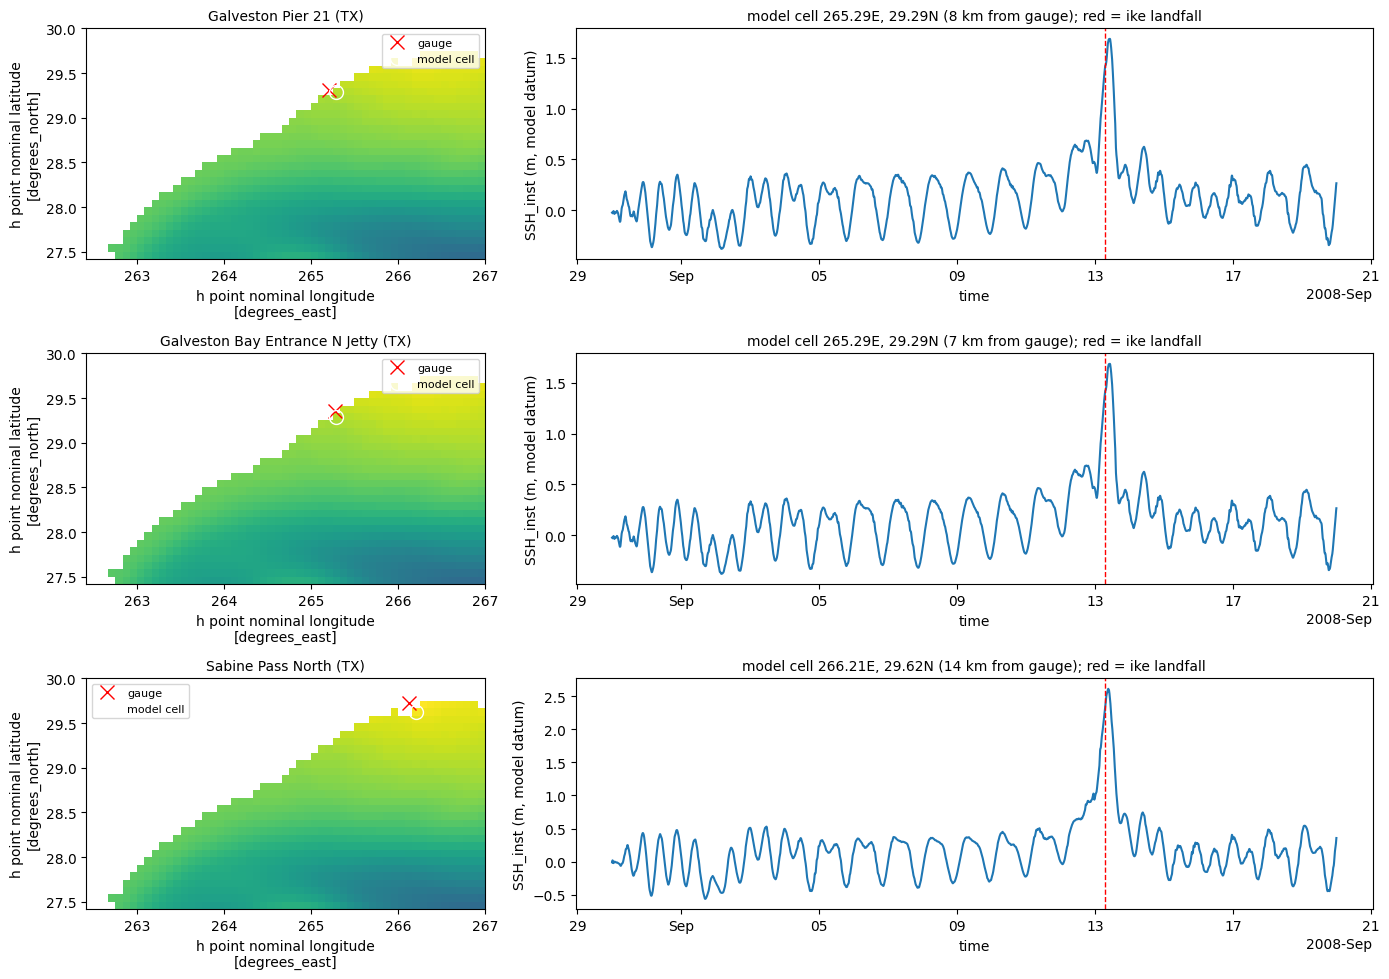

In [4]:
def nearest_wet(ds, lon, lat):
    """Return the nearest wet-cell SSH series and great-circle distance in km."""
    ssh = ds["SSH_inst"]
    grid_lon, grid_lat = np.meshgrid(ds["xh"].values, ds["yh"].values)
    target_lon = (lon + 180.0) % 360.0 - 180.0
    grid_lon = (grid_lon + 180.0) % 360.0 - 180.0
    target_lat_rad = np.deg2rad(lat)
    delta_lat = np.deg2rad(grid_lat) - target_lat_rad
    delta_lon = np.deg2rad(grid_lon) - np.deg2rad(target_lon)
    a = (np.sin(delta_lat / 2.0)**2 + np.cos(target_lat_rad)
         * np.cos(np.deg2rad(grid_lat)) * np.sin(delta_lon / 2.0)**2)
    distance_km = 2.0 * 6371.0 * np.arcsin(np.sqrt(a))
    wet = np.isfinite(ssh.isel(time=0).values)
    distance_km = np.where(wet, distance_km, np.inf)
    iy, ix = np.unravel_index(np.argmin(distance_km), distance_km.shape)
    return ssh.isel(yh=iy, xh=ix), float(distance_km[iy, ix])


gauges = {  # name: (lon 0-360, lat, dataset)
    "Galveston Pier 21 (TX)": (360 - 94.793, 29.31, tx),
    "Galveston Bay Entrance N Jetty (TX)": (360 - 94.725, 29.357, tx),
    "Sabine Pass North (TX)": (360 - 93.87, 29.728, tx),
}
landfall = np.datetime64("2008-09-13T07:00")   # Ike landfall at Galveston about 2008-09-13 07 UTC

fig, axes = plt.subplots(len(gauges), 2, figsize=(14, 3.3 * len(gauges)),
                         gridspec_kw={"width_ratios": [1, 2]})
for row, (name, (lon, lat, ds)) in enumerate(gauges.items()):
    s, km = nearest_wet(ds, lon, lat)
    ds["SSH_inst"].mean("time").plot(ax=axes[row, 0], cmap="viridis", add_colorbar=False)
    axes[row, 0].plot(lon, lat, "rx", ms=10, label="gauge")
    axes[row, 0].plot(float(s.xh), float(s.yh), "wo", mfc="none", ms=10, label="model cell")
    axes[row, 0].set_title(name, fontsize=10)
    axes[row, 0].legend(fontsize=8)
    s.plot(ax=axes[row, 1])
    axes[row, 1].axvline(landfall, color="r", ls="--", lw=1)
    axes[row, 1].set_title(f"model cell {float(s.xh):.2f}E, {float(s.yh):.2f}N ({km:.0f} km from gauge); red = ike landfall",
                           fontsize=10)
    axes[row, 1].set_ylabel("SSH_inst (m, model datum)")
plt.tight_layout()

### 7b. Sea level at the gauges vs NOAA

Uses the model cell nearest each gauge that is ocean (gauges sit in land cells at 1/12 degree).
Both series are anomalies from their calm-period mean, so the datum doesn't matter here.
The printed NOAA station name confirms each ID.

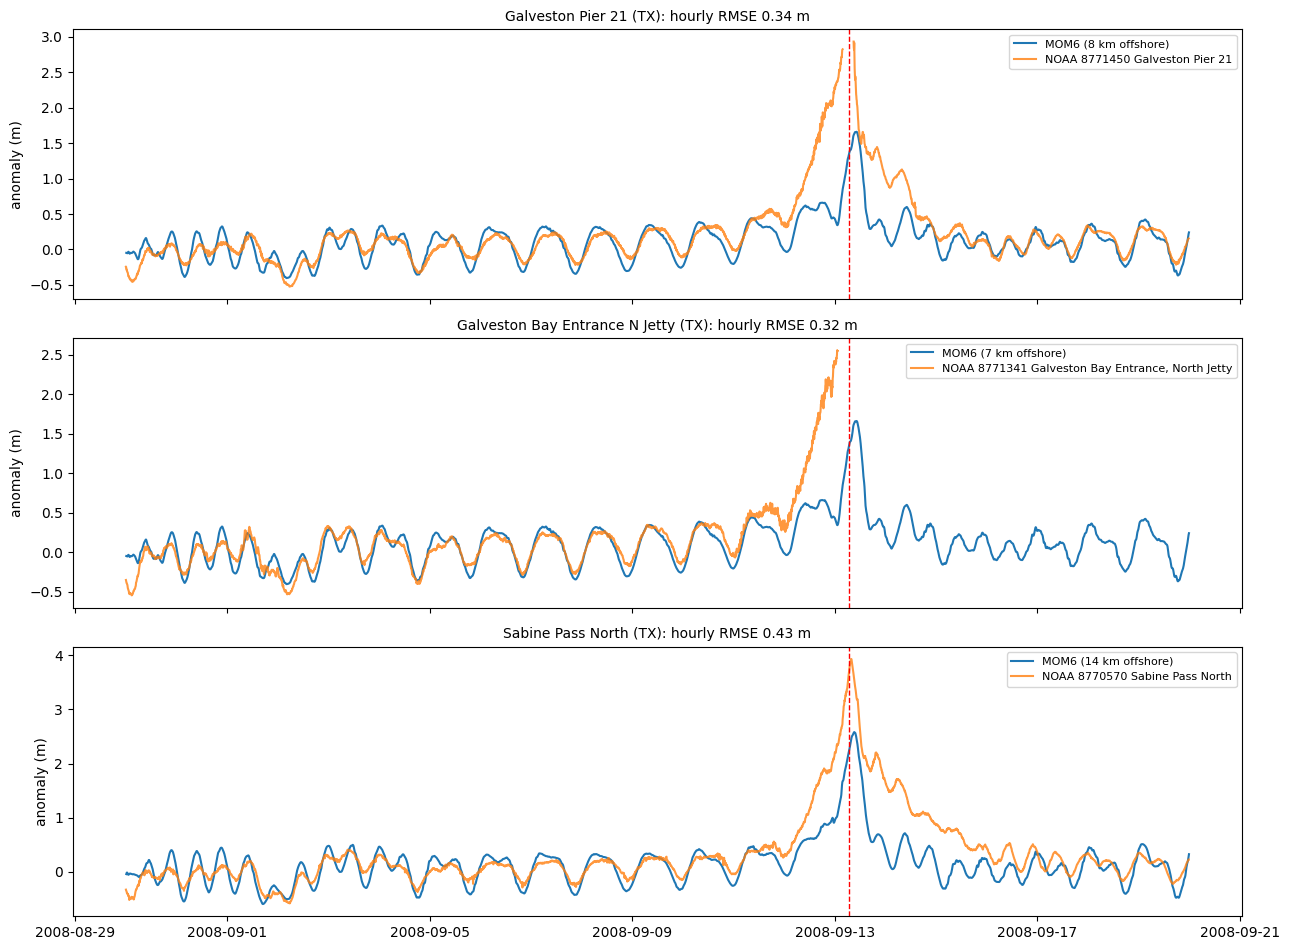

In [5]:
import requests

# Reuse nearest_wet() from section 7a.

def noaa_wl(station, begin, end, datum="MSL"):
    r = requests.get("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter", params=dict(
        product="water_level", station=station, begin_date=begin, end_date=end,
        datum=datum, units="metric", time_zone="gmt", format="json",
        application="MOM6_SFINCS_check"), timeout=60).json()
    if "error" in r:
        print(station, "->", r["error"])
        return None, None
    df = pd.DataFrame(r["data"])
    s = pd.Series(pd.to_numeric(df["v"], errors="coerce").values, index=pd.to_datetime(df["t"]))
    return s, r["metadata"]["name"]


# Ike landfall at Galveston about 2008-09-13 07 UTC
landfall = np.datetime64("2008-09-13T07:00")
calm = slice("2008-09-01", "2008-09-07")
begin, end = "20080830", "20080919"
stations = {  # name: (NOAA id, lon 0-360, lat, dataset)
    "Galveston Pier 21 (TX)": ("8771450", 360 - 94.793, 29.31, tx),
    "Galveston Bay Entrance N Jetty (TX)": ("8771341", 360 - 94.725, 29.357, tx),
    "Sabine Pass North (TX)": ("8770570", 360 - 93.87, 29.728, tx),
}

fig, axes = plt.subplots(len(stations), 1, figsize=(13, 3.2 * len(stations)), sharex=True)
for ax, (name, (sid, lon, lat, ds)) in zip(axes, stations.items()):
    mod, km = nearest_wet(ds, lon, lat)
    mod = mod.to_series()
    ax.plot(mod.index, mod - mod[calm].mean(), label=f"MOM6 ({km:.0f} km offshore)")
    obs, noaa_name = noaa_wl(sid, begin, end)
    title = name
    if obs is not None:
        ax.plot(obs.index, obs - obs[calm].mean(), label=f"NOAA {sid} {noaa_name}", alpha=0.8)
        both = pd.concat([mod.resample("1h").mean() - mod[calm].mean(),
                          obs.resample("1h").mean() - obs[calm].mean()], axis=1).dropna()
        rmse = float(np.sqrt(((both.iloc[:, 0] - both.iloc[:, 1])**2).mean()))
        title += f": hourly RMSE {rmse:.2f} m"
    ax.axvline(landfall, color="r", ls="--", lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("anomaly (m)")
    ax.legend(fontsize=8)
plt.tight_layout()

In [20]:
### 7c. Animation of sea level (whole Gulf, hourly) Anomaly from the run mean, 2008-09-09 to 2008-09-15.
#The GIF is saved in `OUTDIR` and copied to your home folder; download it from the JupyterLab file browser (right-click, then Download).

from matplotlib import animation
from IPython.display import Image

ssh = g["SSH_inst"]
anom = (ssh - ssh.mean("time")).sel(time=slice("2008-09-09", "2008-09-15")).load()

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("0.75")
im = ax.pcolormesh(anom.xh, anom.yh, np.ma.masked_invalid(anom.isel(time=0).values),
                   cmap="RdBu_r", vmin=-0.8, vmax=0.8, shading="nearest")
fig.colorbar(im, ax=ax, label="SSH anomaly from run mean (m)")
ax.plot(360 - 94.793, 29.31, "k^", ms=6)
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
title = ax.set_title("")


def update(i):
    im.set_array(np.ma.masked_invalid(anom.isel(time=i).values))
    title.set_text(f"MOM6 Gulf 1/12 deg, ike: sea level anomaly {str(anom.time.values[i])[:16]} UTC")
    return im, title


anim = animation.FuncAnimation(fig, update, frames=anom.sizes["time"], interval=100)
gif = OUTDIR / f"{CASENAME}_ssh_ike.gif"
anim.save(gif, writer=animation.PillowWriter(fps=10), dpi=80)
plt.close(fig)
shutil.copy(gif, Path.home() / gif.name)
print("saved", gif, "and a copy in your home folder")
Image(filename=str(gif))

NameError: name 'g' is not defined

## Compare with Global Ocean Gridded L 4 Sea Surface Heights And Derived Variables Reprocessed Copernicus Climate Service

In [5]:
#Install the Copernicus toolbox
%pip install -q --upgrade copernicusmarine

SyntaxError: invalid syntax (1282635440.py, line 1)

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import copernicusmarine

# ------------------------------------------------------------
# MOM6 experiment
# ------------------------------------------------------------
WORKSPACE = Path("/glade/work/faezehmaghso/crocodile2026")
CASENAME = "gom12_ike_ERA5full.001"

# Look first in the permanent output folder, then in Derecho scratch.
mom_candidates = [
    WORKSPACE / "mom6_output" / CASENAME /
    f"{CASENAME}.mom6.ssh_hourly.nc",

    Path("/glade/derecho/scratch/faezehmaghso") /
    CASENAME / "run" /
    f"{CASENAME}.mom6.ssh_hourly.nc",
]

MOM_FILE = next((p for p in mom_candidates if p.exists()), None)

if MOM_FILE is None:
    raise FileNotFoundError(
        "Could not find the MOM6 hourly SSH file.\n"
        "Update mom_candidates with its current location."
    )

# ------------------------------------------------------------
# Copernicus output
# ------------------------------------------------------------
COPERNICUS_DIR = WORKSPACE / "validation" / "copernicus_sealevel"
COPERNICUS_DIR.mkdir(parents=True, exist_ok=True)

COPERNICUS_FILE = COPERNICUS_DIR / "copernicus_sla_ike_2008.nc"

# Comparison settings
START_DATE = "2008-08-30"
END_DATE = "2008-09-19"       # 20 September is incomplete in MOM6
BASELINE_START = "2008-09-01"
BASELINE_END = "2008-09-07"
IKE_LANDFALL = pd.Timestamp("2008-09-13 07:00")

print("MOM6 file:", MOM_FILE)
print("Copernicus file:", COPERNICUS_FILE)

MOM6 file: /glade/work/faezehmaghso/crocodile2026/mom6_output/gom12_ike_ERA5full.001/gom12_ike_ERA5full.001.mom6.ssh_hourly.nc
Copernicus file: /glade/work/faezehmaghso/crocodile2026/validation/copernicus_sealevel/copernicus_sla_ike_2008.nc


In [7]:
#Log in to Copernicus
copernicusmarine.login()

INFO - 2026-10-01T16:47:39Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:  [redacted]
Copernicus Marine password:  [not stored]


INFO - 2026-10-01T16:47:56Z - Credentials file stored in the user's private Copernicus Marine configuration directory.


True

In [9]:
#Download the Copernicus Hurricane Ike subset
DATASET_ID = (
    "c3s_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.25deg_P1D"
)

if not COPERNICUS_FILE.exists():
    copernicusmarine.subset(
        dataset_id=DATASET_ID,
        variables=["sla"],
        minimum_longitude=-98.0,
        maximum_longitude=-82.0,
        minimum_latitude=18.0,
        maximum_latitude=31.0,
        start_datetime="2008-08-30T00:00:00",
        end_datetime="2008-09-20T23:59:59",
        output_directory=str(COPERNICUS_DIR),
        output_filename=COPERNICUS_FILE.name,
        netcdf_compression_level=4,
    )
else:
    print("File already exists; download skipped.")

print(COPERNICUS_FILE)

INFO - 2026-10-01T16:49:17Z - Selected dataset version: "202411"
INFO - 2026-10-01T16:49:17Z - Selected dataset part: "default"
INFO - 2026-10-01T16:49:45Z - Total size of the download: 300.55 KB.


/glade/work/faezehmaghso/crocodile2026/validation/copernicus_sealevel/copernicus_sla_ike_2008.nc


In [10]:
def convert_time_to_pandas(obj):
    """Convert xarray time coordinate to pandas datetime."""
    values = obj.time.values

    if np.issubdtype(values.dtype, np.datetime64):
        dates = pd.to_datetime(values)
    else:
        dates = pd.to_datetime([
            (
                f"{v.year:04d}-{v.month:02d}-{v.day:02d} "
                f"{getattr(v, 'hour', 0):02d}:"
                f"{getattr(v, 'minute', 0):02d}:"
                f"{getattr(v, 'second', 0):02d}"
            )
            for v in values
        ])

    return obj.assign_coords(time=dates)

In [11]:
#Calculate MOM6 daily-average SSH

mom = xr.open_dataset(MOM_FILE)
mom = convert_time_to_pandas(mom)

print("Available MOM6 variables:")
print(list(mom.data_vars))

SSH_VARIABLE = "SSH_inst"

if SSH_VARIABLE not in mom:
    raise KeyError(
        f"{SSH_VARIABLE!r} was not found. "
        f"Available variables: {list(mom.data_vars)}"
    )

# Select only complete comparison days.
mom_hourly = mom[SSH_VARIABLE].sel(
    time=slice(
        f"{START_DATE}T00:00:00",
        f"{END_DATE}T23:59:59",
    )
)

# Daily mean from hourly/10-minute MOM6 output.
mom_daily = mom_hourly.resample(time="1D").mean(keep_attrs=True)

# Rename MOM6 horizontal dimensions to standard names.
rename_dimensions = {}

if "xh" in mom_daily.dims:
    rename_dimensions["xh"] = "longitude"

if "yh" in mom_daily.dims:
    rename_dimensions["yh"] = "latitude"

mom_daily = mom_daily.rename(rename_dimensions)

if "longitude" not in mom_daily.coords:
    raise ValueError("MOM6 longitude coordinate was not found.")

if "latitude" not in mom_daily.coords:
    raise ValueError("MOM6 latitude coordinate was not found.")

# Convert 0–360 longitude to −180–180.
mom_daily = mom_daily.assign_coords(
    longitude=((mom_daily.longitude + 180.0) % 360.0) - 180.0
)

mom_daily = mom_daily.sortby("longitude").sortby("latitude")

# Confirm units.
units = str(mom_daily.attrs.get("units", "m")).lower().strip()

if units in {"cm", "centimeter", "centimeters"}:
    mom_daily = mom_daily / 100.0
    mom_daily.attrs["units"] = "m"
elif units in {"mm", "millimeter", "millimeters"}:
    mom_daily = mom_daily / 1000.0
    mom_daily.attrs["units"] = "m"

mom_daily.name = "MOM6_daily_SSH"

print(mom_daily)
print(
    "MOM6 period:",
    pd.Timestamp(mom_daily.time.min().values),
    "to",
    pd.Timestamp(mom_daily.time.max().values),
)

Available MOM6 variables:
['SSH_inst']
<xarray.DataArray 'MOM6_daily_SSH' (time: 20, latitude: 156, longitude: 192)> Size: 2MB
array([[[       nan,        nan,        nan, ..., 0.385769  ,
         0.38689366, 0.38874635],
        [       nan,        nan,        nan, ..., 0.3870314 ,
         0.38804188, 0.38999322],
        [       nan,        nan,        nan, ..., 0.38881466,
         0.3891258 , 0.39091352],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ..., 0.39718804,
         0.3975915 , 0.3983747 ],
        [       nan,        nan,        nan, ..., 0.39481333,
         0.39578247, 0.3976463 ],
        [       nan,        nan,        nan, ..., 0.3930944 ,
         0.39366925, 0.39573

In [12]:
cop = xr.open_dataset(COPERNICUS_FILE)
cop = convert_time_to_pandas(cop)

print("Copernicus variables:")
print(list(cop.data_vars))

if "sla" not in cop:
    raise KeyError(
        f"'sla' was not found. Available variables: {list(cop.data_vars)}"
    )

cop_sla = cop["sla"].sel(
    time=slice(
        f"{START_DATE}T00:00:00",
        "2008-09-20T23:59:59",
    )
)

# Copernicus daily fields are often timestamped at midday.
# Normalize them to the calendar date for alignment with MOM6.
cop_sla = cop_sla.assign_coords(
    time=pd.DatetimeIndex(cop_sla.time.values).normalize()
)

cop_sla = cop_sla.sortby("longitude").sortby("latitude")
cop_sla.name = "Copernicus_SLA"

print(cop_sla)

Copernicus variables:
['sla']
<xarray.DataArray 'Copernicus_SLA' (time: 22, latitude: 52, longitude: 64)> Size: 586kB
[73216 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 176B 2008-08-30 2008-08-31 ... 2008-09-20
  * latitude   (latitude) float32 208B 18.12 18.38 18.62 ... 30.38 30.62 30.88
  * longitude  (longitude) float32 256B -97.88 -97.62 -97.38 ... -82.38 -82.12
Attributes:
    ancillary_variables:  err_sla
    comment:              The sea level anomaly is the sea surface height abo...
    grid_mapping:         crs
    long_name:            Sea level anomaly
    standard_name:        sea_surface_height_above_sea_level
    units:                m


In [13]:
#Put both datasets on a common reference level

baseline = slice(BASELINE_START, BASELINE_END)

mom_baseline = mom_daily.sel(time=baseline).mean("time")
cop_baseline = cop_sla.sel(time=baseline).mean("time")

mom_anomaly = mom_daily - mom_baseline
cop_anomaly = cop_sla - cop_baseline

mom_anomaly.name = "MOM6_SSH_change"
cop_anomaly.name = "Copernicus_SLA_change"

print(
    f"Reference period: {BASELINE_START} through {BASELINE_END}"
)

Reference period: 2008-09-01 through 2008-09-07


In [14]:
#Interpolate MOM6 to the Copernicus grid

In [15]:
# Interpolate MOM6 from its approximately 9-km grid
# to the Copernicus 0.25-degree grid.
mom_on_copernicus = mom_anomaly.interp(
    longitude=cop_anomaly.longitude,
    latitude=cop_anomaly.latitude,
)

# Keep only dates available in both datasets.
mom_compare, cop_compare = xr.align(
    mom_on_copernicus,
    cop_anomaly,
    join="inner",
)

# Compare only cells where both products contain valid water values.
common_mask = np.isfinite(mom_compare) & np.isfinite(cop_compare)

mom_compare = mom_compare.where(common_mask)
cop_compare = cop_compare.where(common_mask)

difference = mom_compare - cop_compare
difference.name = "MOM6_minus_Copernicus"

print("Number of common days:", mom_compare.sizes["time"])
print(
    "Common period:",
    pd.Timestamp(mom_compare.time.min().values).date(),
    "to",
    pd.Timestamp(mom_compare.time.max().values).date(),
)

Number of common days: 20
Common period: 2008-08-30 to 2008-09-18


In [16]:
#Calculate daily statistics
spatial_dims = ("latitude", "longitude")

# Latitude weighting accounts approximately for grid-cell area.
latitude_weights = np.cos(
    np.deg2rad(cop_compare.latitude)
).clip(min=0)

bias_daily = difference.weighted(latitude_weights).mean(spatial_dims)

rmse_daily = np.sqrt(
    (difference**2).weighted(latitude_weights).mean(spatial_dims)
)

# Daily spatial-pattern correlation.
mom_stacked = mom_compare.stack(
    comparison_point=spatial_dims
)
cop_stacked = cop_compare.stack(
    comparison_point=spatial_dims
)

correlation_daily = xr.corr(
    mom_stacked,
    cop_stacked,
    dim="comparison_point",
)

valid_points = common_mask.sum(spatial_dims)

statistics = pd.DataFrame(
    {
        "MOM6 mean change (m)": (
            mom_compare
            .weighted(latitude_weights)
            .mean(spatial_dims)
            .values
        ),
        "Copernicus mean change (m)": (
            cop_compare
            .weighted(latitude_weights)
            .mean(spatial_dims)
            .values
        ),
        "Bias MOM6-Copernicus (m)": bias_daily.values,
        "RMSE (m)": rmse_daily.values,
        "Spatial correlation": correlation_daily.values,
        "Valid grid cells": valid_points.values,
    },
    index=pd.to_datetime(mom_compare.time.values),
)

statistics.index.name = "Date"

display(statistics.round(4))

,MOM6 mean change (m),Copernicus mean change (m),Bias MOM6-Copernicus (m),RMSE (m),Spatial correlation,Valid grid cells
Date,,,,,,
2008-08-30,-0.0039,-0.0121,0.0082,0.0791,-0.0436,2424
2008-08-31,-0.0283,-0.0104,-0.0179,0.0513,0.1227,2424
2008-09-01,-0.0131,-0.0081,-0.0050,0.0409,-0.1815,2424
2008-09-02,0.0004,-0.0055,0.0059,0.0247,-0.0349,2424
2008-09-03,0.0082,-0.0030,0.0112,0.0170,0.3313,2424
2008-09-04,0.0112,-0.0000,0.0112,0.0165,-0.1040,2424
2008-09-05,-0.0101,0.0028,-0.0129,0.0221,-0.2685,2424
2008-09-06,-0.0146,0.0053,-0.0199,0.0299,0.0198,2424
2008-09-07,0.0179,0.0085,0.0094,0.0288,0.3485,2424


In [17]:
#Overall statistics
valid = (
    np.isfinite(mom_compare.values) &
    np.isfinite(cop_compare.values)
)

model_values = mom_compare.values[valid]
observed_values = cop_compare.values[valid]

overall_bias = np.mean(model_values - observed_values)
overall_rmse = np.sqrt(
    np.mean((model_values - observed_values)**2)
)
overall_correlation = np.corrcoef(
    model_values,
    observed_values,
)[0, 1]

print("IKE-window comparison")
print("---------------------")
print(f"Bias:        {overall_bias:8.4f} m")
print(f"RMSE:        {overall_rmse:8.4f} m")
print(f"Correlation: {overall_correlation:8.3f}")
print(f"Samples:     {model_values.size:,}")

IKE-window comparison
---------------------
Bias:          0.0018 m
RMSE:          0.0694 m
Correlation:    0.456
Samples:     48,480


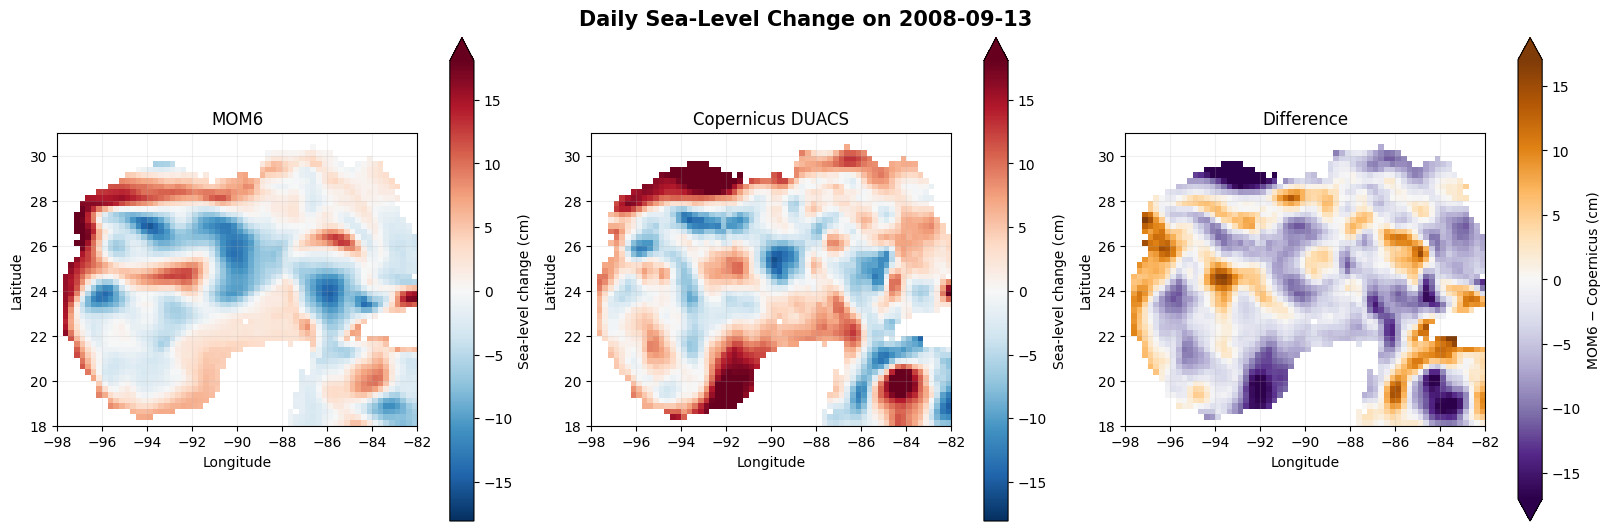

Saved: /glade/work/faezehmaghso/crocodile2026/figures/mom6_copernicus/ike_mom6_vs_copernicus_maps_2008-09-13.png


In [19]:
#Maps for Ike landfall day
MAP_DATE = "2008-09-13"

mom_map = mom_compare.sel(time=MAP_DATE, method="nearest") * 100
cop_map = cop_compare.sel(time=MAP_DATE, method="nearest") * 100
difference_map = mom_map - cop_map

combined_values = np.concatenate([
    mom_map.values[np.isfinite(mom_map.values)],
    cop_map.values[np.isfinite(cop_map.values)],
])

field_limit = np.nanpercentile(
    np.abs(combined_values),
    98,
)

difference_limit = np.nanpercentile(
    np.abs(difference_map.values),
    98,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.2),
    constrained_layout=True,
)

mom_map.plot.pcolormesh(
    ax=axes[0],
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-field_limit,
    vmax=field_limit,
    cbar_kwargs={"label": "Sea-level change (cm)"},
)

cop_map.plot.pcolormesh(
    ax=axes[1],
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-field_limit,
    vmax=field_limit,
    cbar_kwargs={"label": "Sea-level change (cm)"},
)

difference_map.plot.pcolormesh(
    ax=axes[2],
    x="longitude",
    y="latitude",
    cmap="PuOr_r",
    vmin=-difference_limit,
    vmax=difference_limit,
    cbar_kwargs={"label": "MOM6 − Copernicus (cm)"},
)

axes[0].set_title("MOM6")
axes[1].set_title("Copernicus DUACS")
axes[2].set_title("Difference")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)

fig.suptitle(
    f"Daily Sea-Level Change on {MAP_DATE}",
    fontsize=15,
    fontweight="bold",
)

output = FIGURE_DIR / f"ike_mom6_vs_copernicus_maps_{MAP_DATE}.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output)